In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

# Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("deep")

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

print("✅ Libraries loaded successfully!")
print("✅ Academic publication style configured")

✅ Libraries loaded successfully!
✅ Academic publication style configured


In [3]:
# Load the detailed results
df = pd.read_csv('../results/metrics/enhanced_results_detailed_20251205_123928.csv')
print(f"📁 Loaded {len(df)} model results")
print(f"📊 Targets: {df['target'].unique().tolist()}")
print(f"🤖 Models: {df['model'].nunique()} unique models")

📁 Loaded 112 model results
📊 Targets: ['valence', 'energy', 'danceability', 'popularity']
🤖 Models: 28 unique models


---
## 🏆 Best Models Summary (Quick Overview)

In [4]:
# Find best model for each target
best_models = df.loc[df.groupby('target')['r2'].idxmax()][['target', 'model', 'r2', 'rmse', 'mae']]
best_models = best_models.sort_values('r2', ascending=False)

# Style the dataframe
def highlight_best(s):
    return ['background-color: #90EE90; font-weight: bold' if i == s.name else '' for i in range(len(s))]

styled_best = best_models.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}'
}).set_caption('🏆 Best Model Per Target').set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#2E86AB')]}
])

display(styled_best)

,target,model,r2,rmse,mae
45,energy,XGBoost_tuned,0.8487,0.0952,0.0716
73,danceability,XGBoost_tuned,0.6092,0.1070,0.0842
17,valence,XGBoost_tuned,0.4659,0.1818,0.1454
102,popularity,CatBoost,0.0783,1.4303,1.2502


---
## 🎭 Valence Models (Emotional Positivity)

In [5]:
def create_styled_table(df, target, sort_by='r2', ascending=False):
    """Create a beautifully styled table for a specific target"""
    target_df = df[df['target'] == target].copy()
    target_df = target_df.sort_values(sort_by, ascending=ascending)
    
    # Select key columns
    cols = ['model', 'r2', 'rmse', 'mae', 'explained_variance', 'train_time_seconds']
    target_df = target_df[cols].reset_index(drop=True)
    target_df['rank'] = range(1, len(target_df) + 1)
    target_df = target_df[['rank'] + cols]
    
    # Color coding function
    def color_r2(val):
        if val >= 0.6:
            return 'background-color: #90EE90'  # Green
        elif val >= 0.4:
            return 'background-color: #FFFFE0'  # Light yellow
        elif val >= 0.2:
            return 'background-color: #FFD700'  # Gold
        elif val >= 0:
            return 'background-color: #FFA500'  # Orange
        else:
            return 'background-color: #FF6B6B'  # Red
    
    styled = target_df.style.format({
        'r2': '{:.4f}',
        'rmse': '{:.4f}',
        'mae': '{:.4f}',
        'explained_variance': '{:.4f}',
        'train_time_seconds': '{:.1f}s'
    }).applymap(color_r2, subset=['r2']).set_caption(
        f'📊 {target.upper()} Models - Sorted by R²'
    ).set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4A90D9'), ('color', 'white')]},
    ])
    
    return styled

display(create_styled_table(df, 'valence'))

,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.4659,0.1818,0.1454,0.4660,767.2s
1,2,CatBoost_tuned,0.4438,0.1855,0.1495,0.4438,670.0s
2,3,LightGBM_tuned,0.4425,0.1858,0.1497,0.4426,84.9s
3,4,CatBoost,0.4414,0.1859,0.1499,0.4415,161.1s
4,5,ExtraTrees,0.4189,0.1896,0.1513,0.4190,989.3s
5,6,RandomForest,0.4157,0.1902,0.1532,0.4158,5239.4s
6,7,MLPRegressor_tuned,0.4090,0.1913,0.1525,0.4104,113.3s
7,8,MLPRegressor,0.4084,0.1914,0.1535,0.4092,58.0s
8,9,XGBoost,0.4083,0.1914,0.1541,0.4083,72.3s
9,10,LightGBM,0.4052,0.1919,0.1556,0.4052,22.2s


---
## ⚡ Energy Models (Intensity)

In [6]:
display(create_styled_table(df, 'energy'))

,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.8487,0.0952,0.0716,0.8488,411.7s
1,2,CatBoost_tuned,0.8476,0.0956,0.0718,0.8476,652.4s
2,3,CatBoost,0.8470,0.0958,0.0721,0.8470,149.0s
3,4,LightGBM_tuned,0.8466,0.0959,0.0723,0.8466,46.6s
4,5,LightGBM,0.8390,0.0982,0.0740,0.8390,20.6s
5,6,XGBoost,0.8383,0.0984,0.0740,0.8383,63.2s
6,7,ExtraTrees,0.8369,0.0989,0.0731,0.8370,1006.1s
7,8,RandomForest,0.8351,0.0994,0.0743,0.8351,4790.5s
8,9,MLPRegressor,0.8324,0.1002,0.0760,0.8324,69.2s
9,10,MLPRegressor_tuned,0.8314,0.1005,0.0759,0.8314,173.8s


---
## 💃 Danceability Models

In [7]:
display(create_styled_table(df, 'danceability'))

,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.6092,0.1070,0.0842,0.6092,478.8s
1,2,LightGBM_tuned,0.6016,0.1080,0.0851,0.6016,55.7s
2,3,CatBoost_tuned,0.6015,0.1080,0.0851,0.6016,670.2s
3,4,CatBoost,0.5998,0.1083,0.0854,0.5998,153.4s
4,5,ExtraTrees,0.5834,0.1104,0.0852,0.5834,996.8s
5,6,XGBoost,0.5787,0.1111,0.0875,0.5788,64.7s
6,7,RandomForest,0.5778,0.1112,0.0869,0.5779,4618.2s
7,8,LightGBM,0.5707,0.1121,0.0888,0.5708,20.8s
8,9,MLPRegressor_tuned,0.5650,0.1128,0.0890,0.5654,134.1s
9,10,MLPRegressor,0.5638,0.1130,0.0891,0.5638,68.3s


---
## 🌟 Popularity Models (Hardest Target)

In [8]:
display(create_styled_table(df, 'popularity'))

,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,CatBoost,0.0783,1.4303,1.2502,0.0791,153.3s
1,2,CatBoost_tuned,0.0782,1.4303,1.2521,0.0791,491.2s
2,3,LightGBM_tuned,0.0770,1.4313,1.2544,0.0779,42.3s
3,4,LightGBM,0.0746,1.4331,1.2597,0.0754,19.7s
4,5,XGBoost_tuned,0.0727,1.4346,1.2571,0.0737,196.7s
5,6,ExtraTrees_tuned,0.0658,1.4399,1.2712,0.0666,536.5s
6,7,MLPRegressor,0.0627,1.4423,1.2556,0.0633,37.8s
7,8,XGBoost,0.0617,1.4430,1.2571,0.0626,62.0s
8,9,MLPRegressor_tuned,0.0579,1.4460,1.2553,0.0590,78.4s
9,10,LinearSVR_tuned,0.0499,1.4521,1.2858,0.0503,78.6s


---
## 📈 Visual Comparison: R² Scores Across All Targets

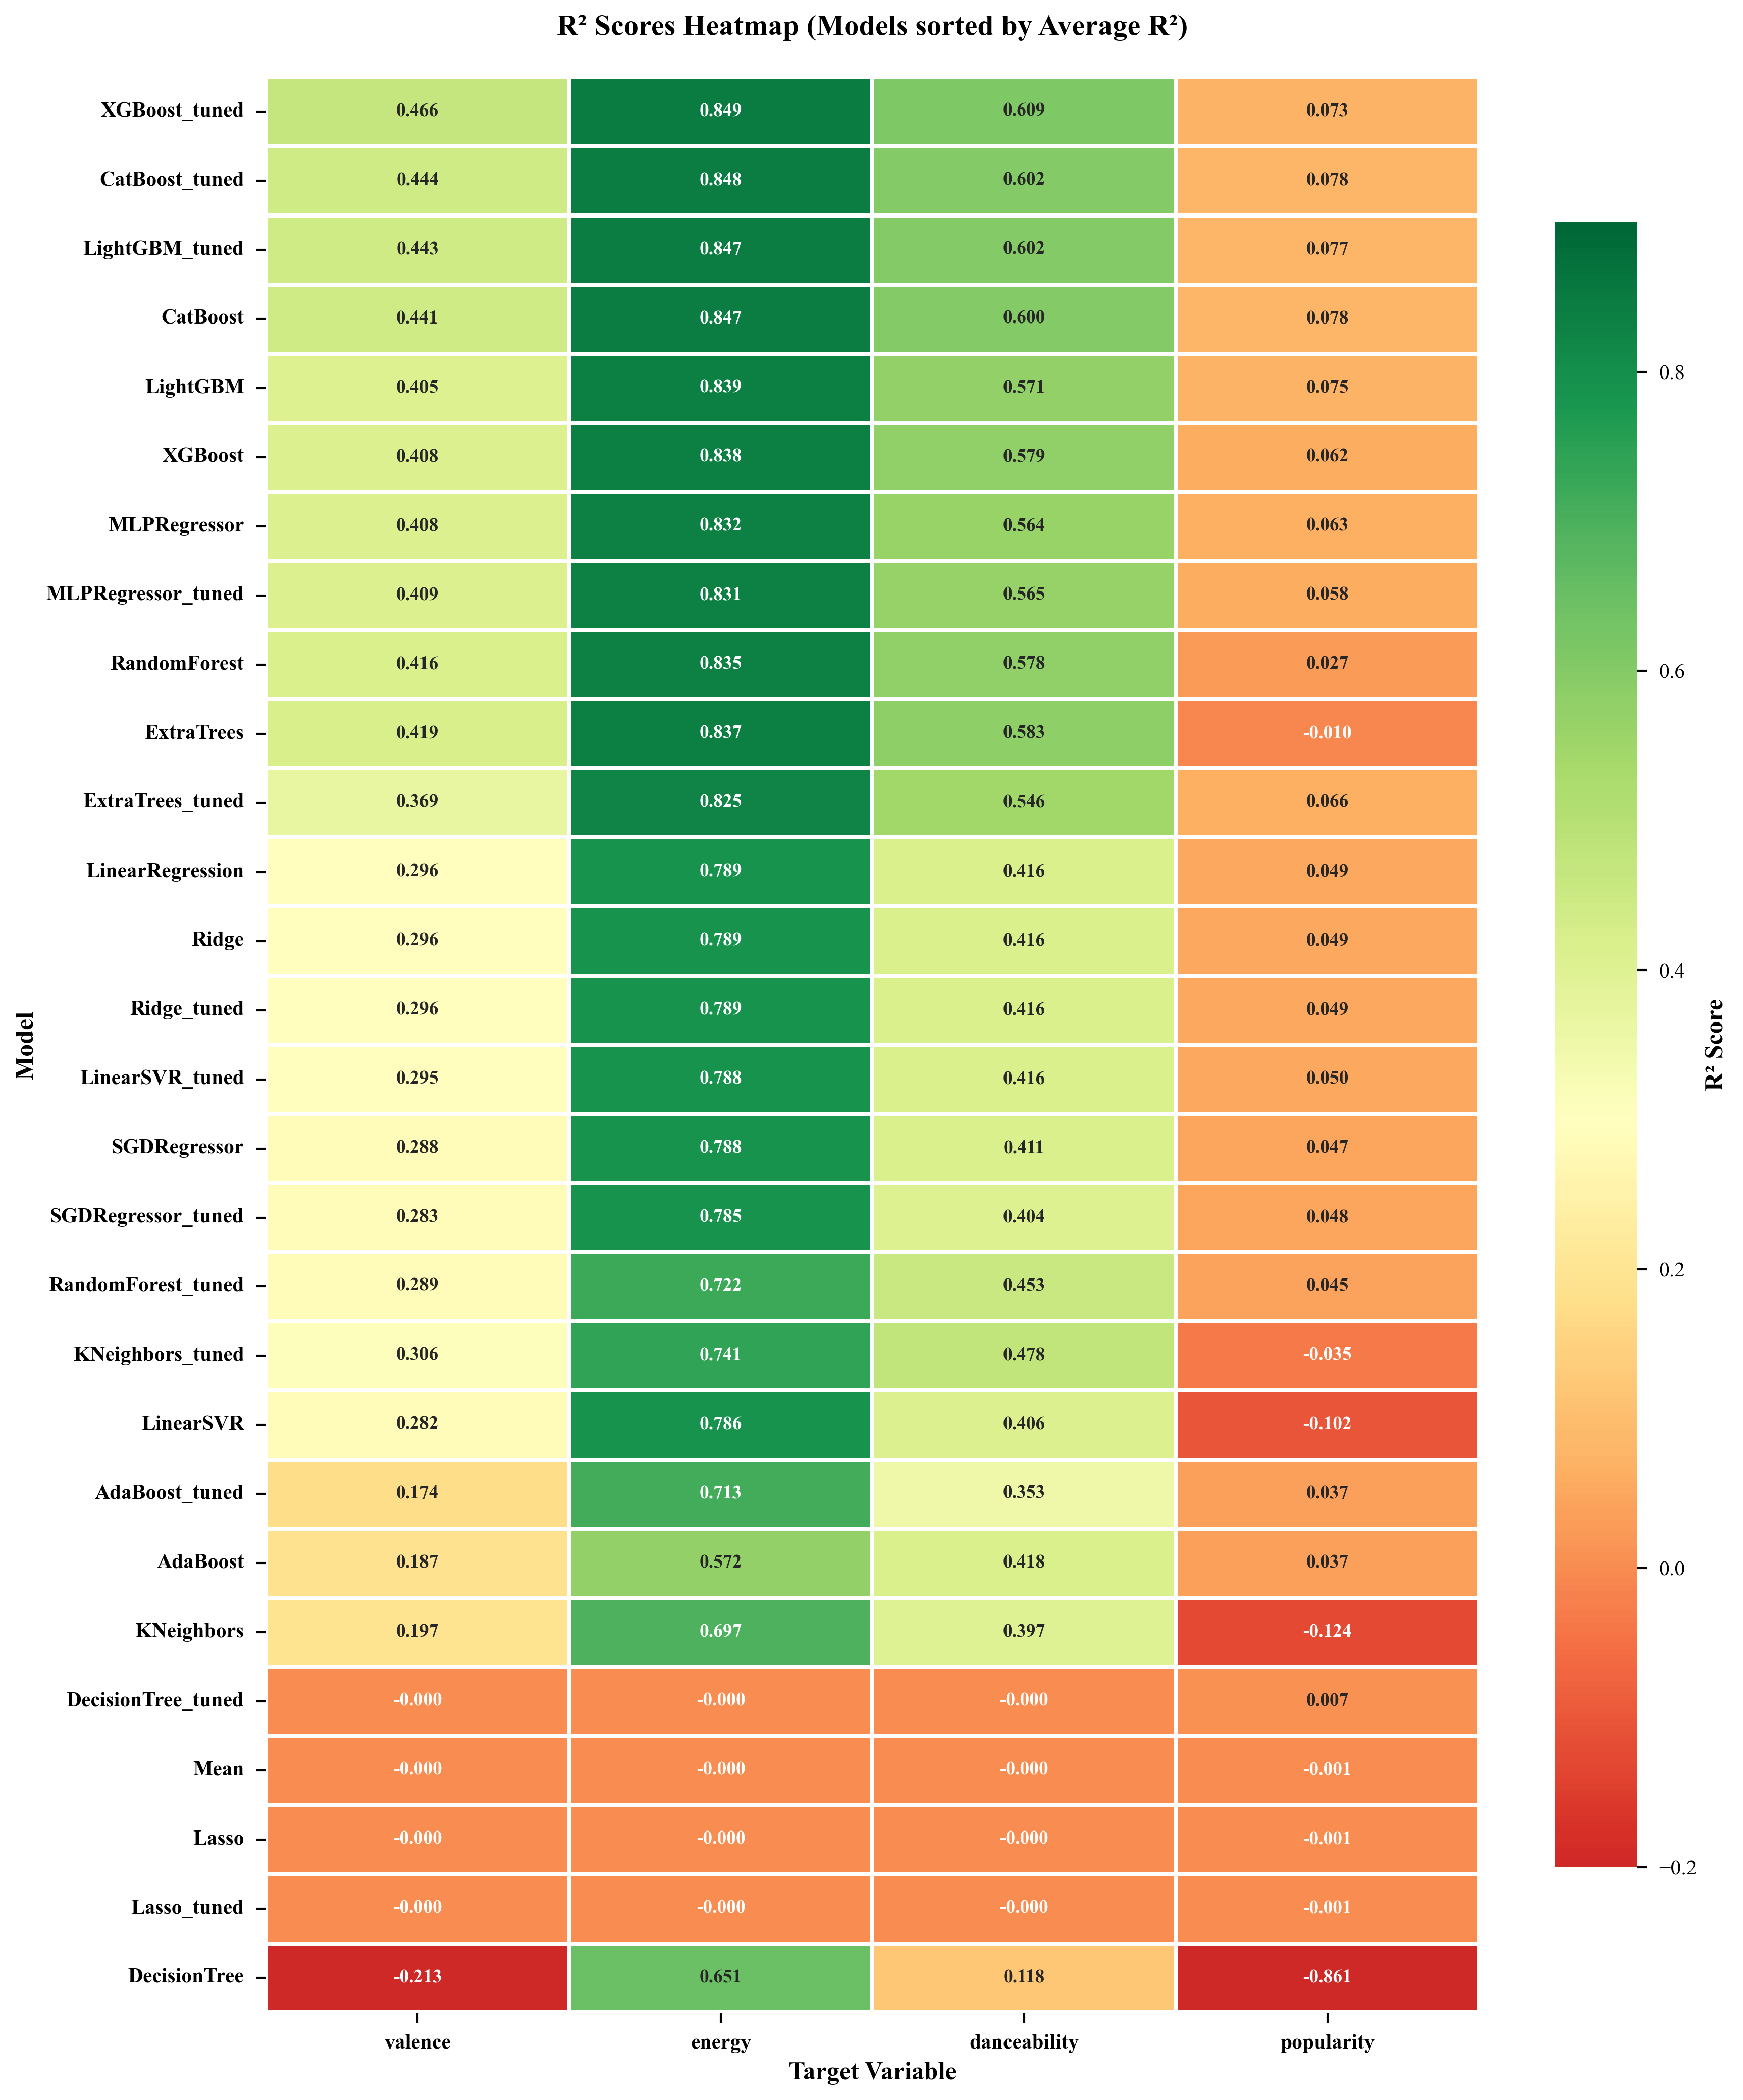

💾 Saved: results/figures/enhanced_r2_heatmap.png


In [9]:
# Create R² comparison heatmap
pivot_r2 = df.pivot(index='model', columns='target', values='r2')
pivot_r2 = pivot_r2[['valence', 'energy', 'danceability', 'popularity']]  # Order columns

# Sort by average R²
pivot_r2['avg_r2'] = pivot_r2.mean(axis=1)
pivot_r2 = pivot_r2.sort_values('avg_r2', ascending=False)
pivot_r2 = pivot_r2.drop('avg_r2', axis=1)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn', center=0.3,
            linewidths=1.5, linecolor='white', ax=ax, vmin=-0.2, vmax=0.9,
            cbar_kws={'label': 'R² Score', 'shrink': 0.85},
            annot_kws={'fontsize': 9, 'weight': 'bold'})
ax.set_title('R² Scores Heatmap (Models sorted by Average R²)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Target Variable', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
plt.yticks(rotation=0, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/enhanced_r2_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_r2_heatmap.png")

---
## 📊 Top 5 Models Bar Chart Per Target

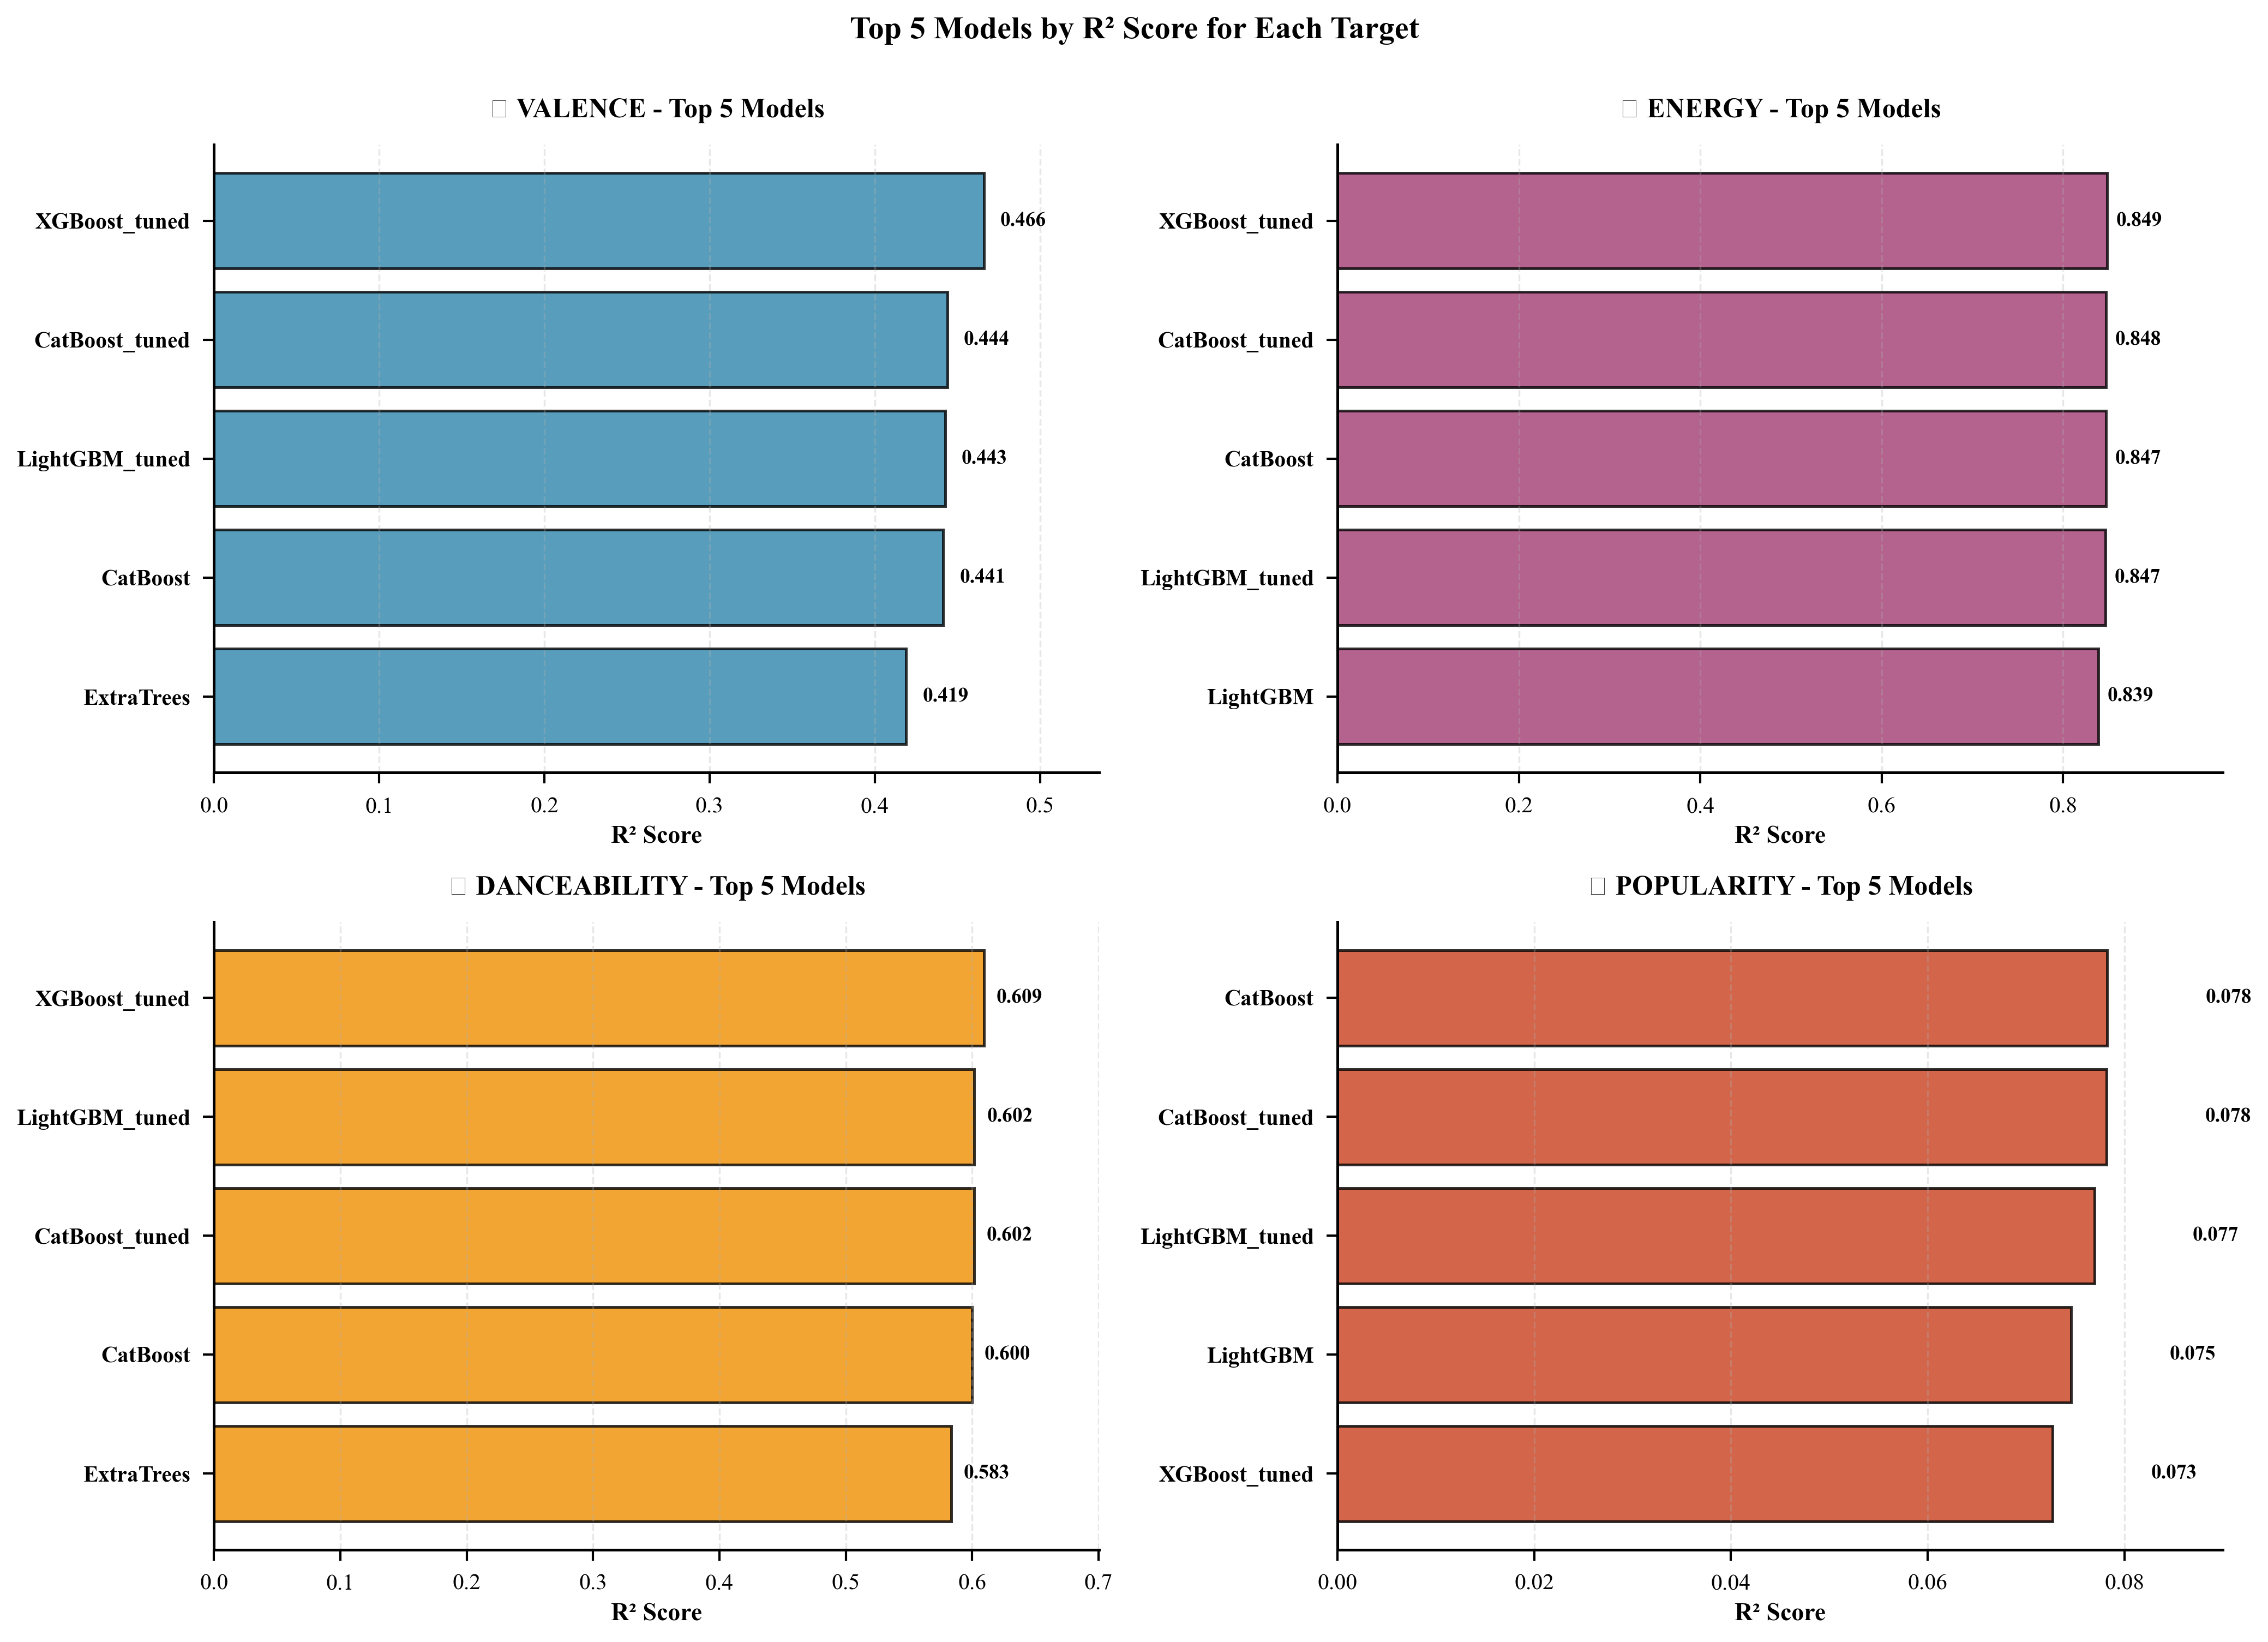

💾 Saved: results/figures/enhanced_top5_models.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
targets = ['valence', 'energy', 'danceability', 'popularity']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
emojis = ['🎭', '⚡', '💃', '🌟']

for ax, target, color, emoji in zip(axes.flatten(), targets, colors, emojis):
    top5 = df[df['target'] == target].nlargest(5, 'r2')
    
    bars = ax.barh(top5['model'], top5['r2'], color=color, edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_xlabel('R² Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{emoji} {target.upper()} - Top 5 Models', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlim(0, max(top5['r2']) * 1.15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top5['r2']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.suptitle('Top 5 Models by R² Score for Each Target', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/enhanced_top5_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_top5_models.png")

---
## ⏱️ Training Time Analysis

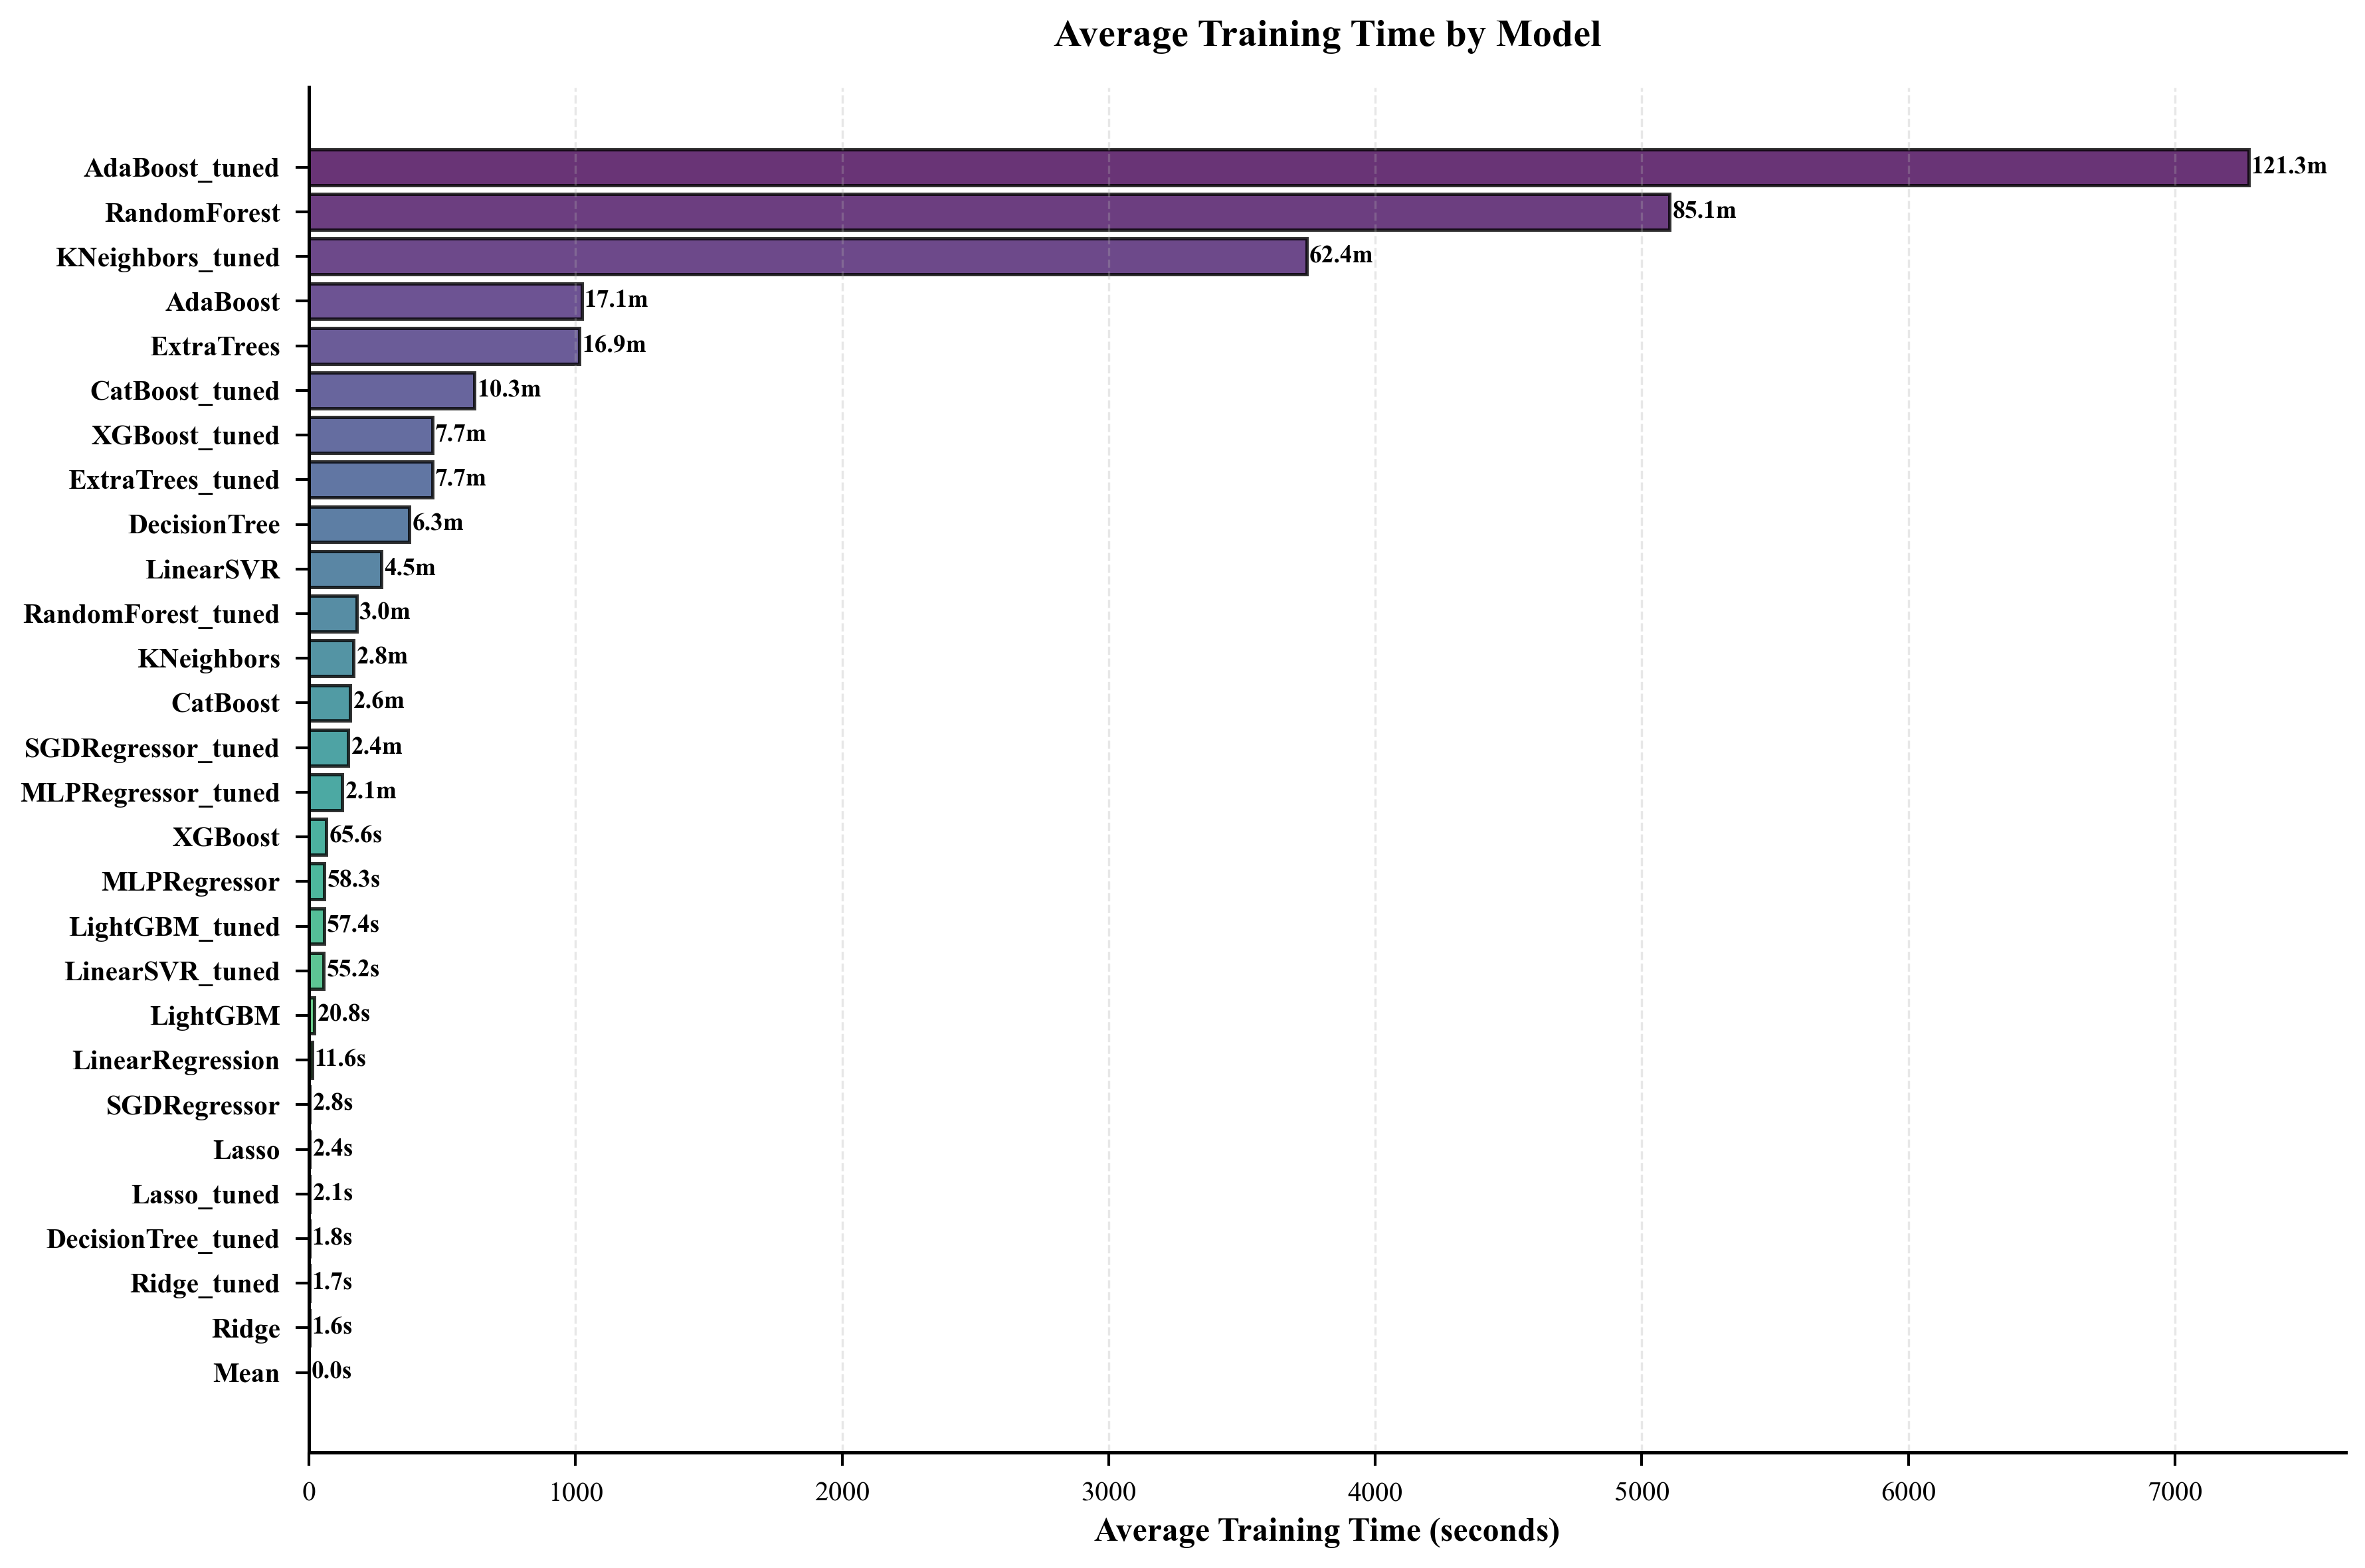

💾 Saved: results/figures/enhanced_training_time.png


In [11]:
# Aggregate training time by model
time_by_model = df.groupby('model')['train_time_seconds'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(time_by_model)))
bars = ax.barh(time_by_model.index, time_by_model.values, color=colors, edgecolor='black', alpha=0.8, linewidth=1.2)
ax.set_xlabel('Average Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Average Training Time by Model', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for bar, val in zip(bars, time_by_model.values):
    if val > 100:
        label = f'{val/60:.1f}m'
    else:
        label = f'{val:.1f}s'
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9, fontweight='bold')

plt.setp(ax.get_yticklabels(), fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/enhanced_training_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_training_time.png")

---
## 📉 RMSE Comparison

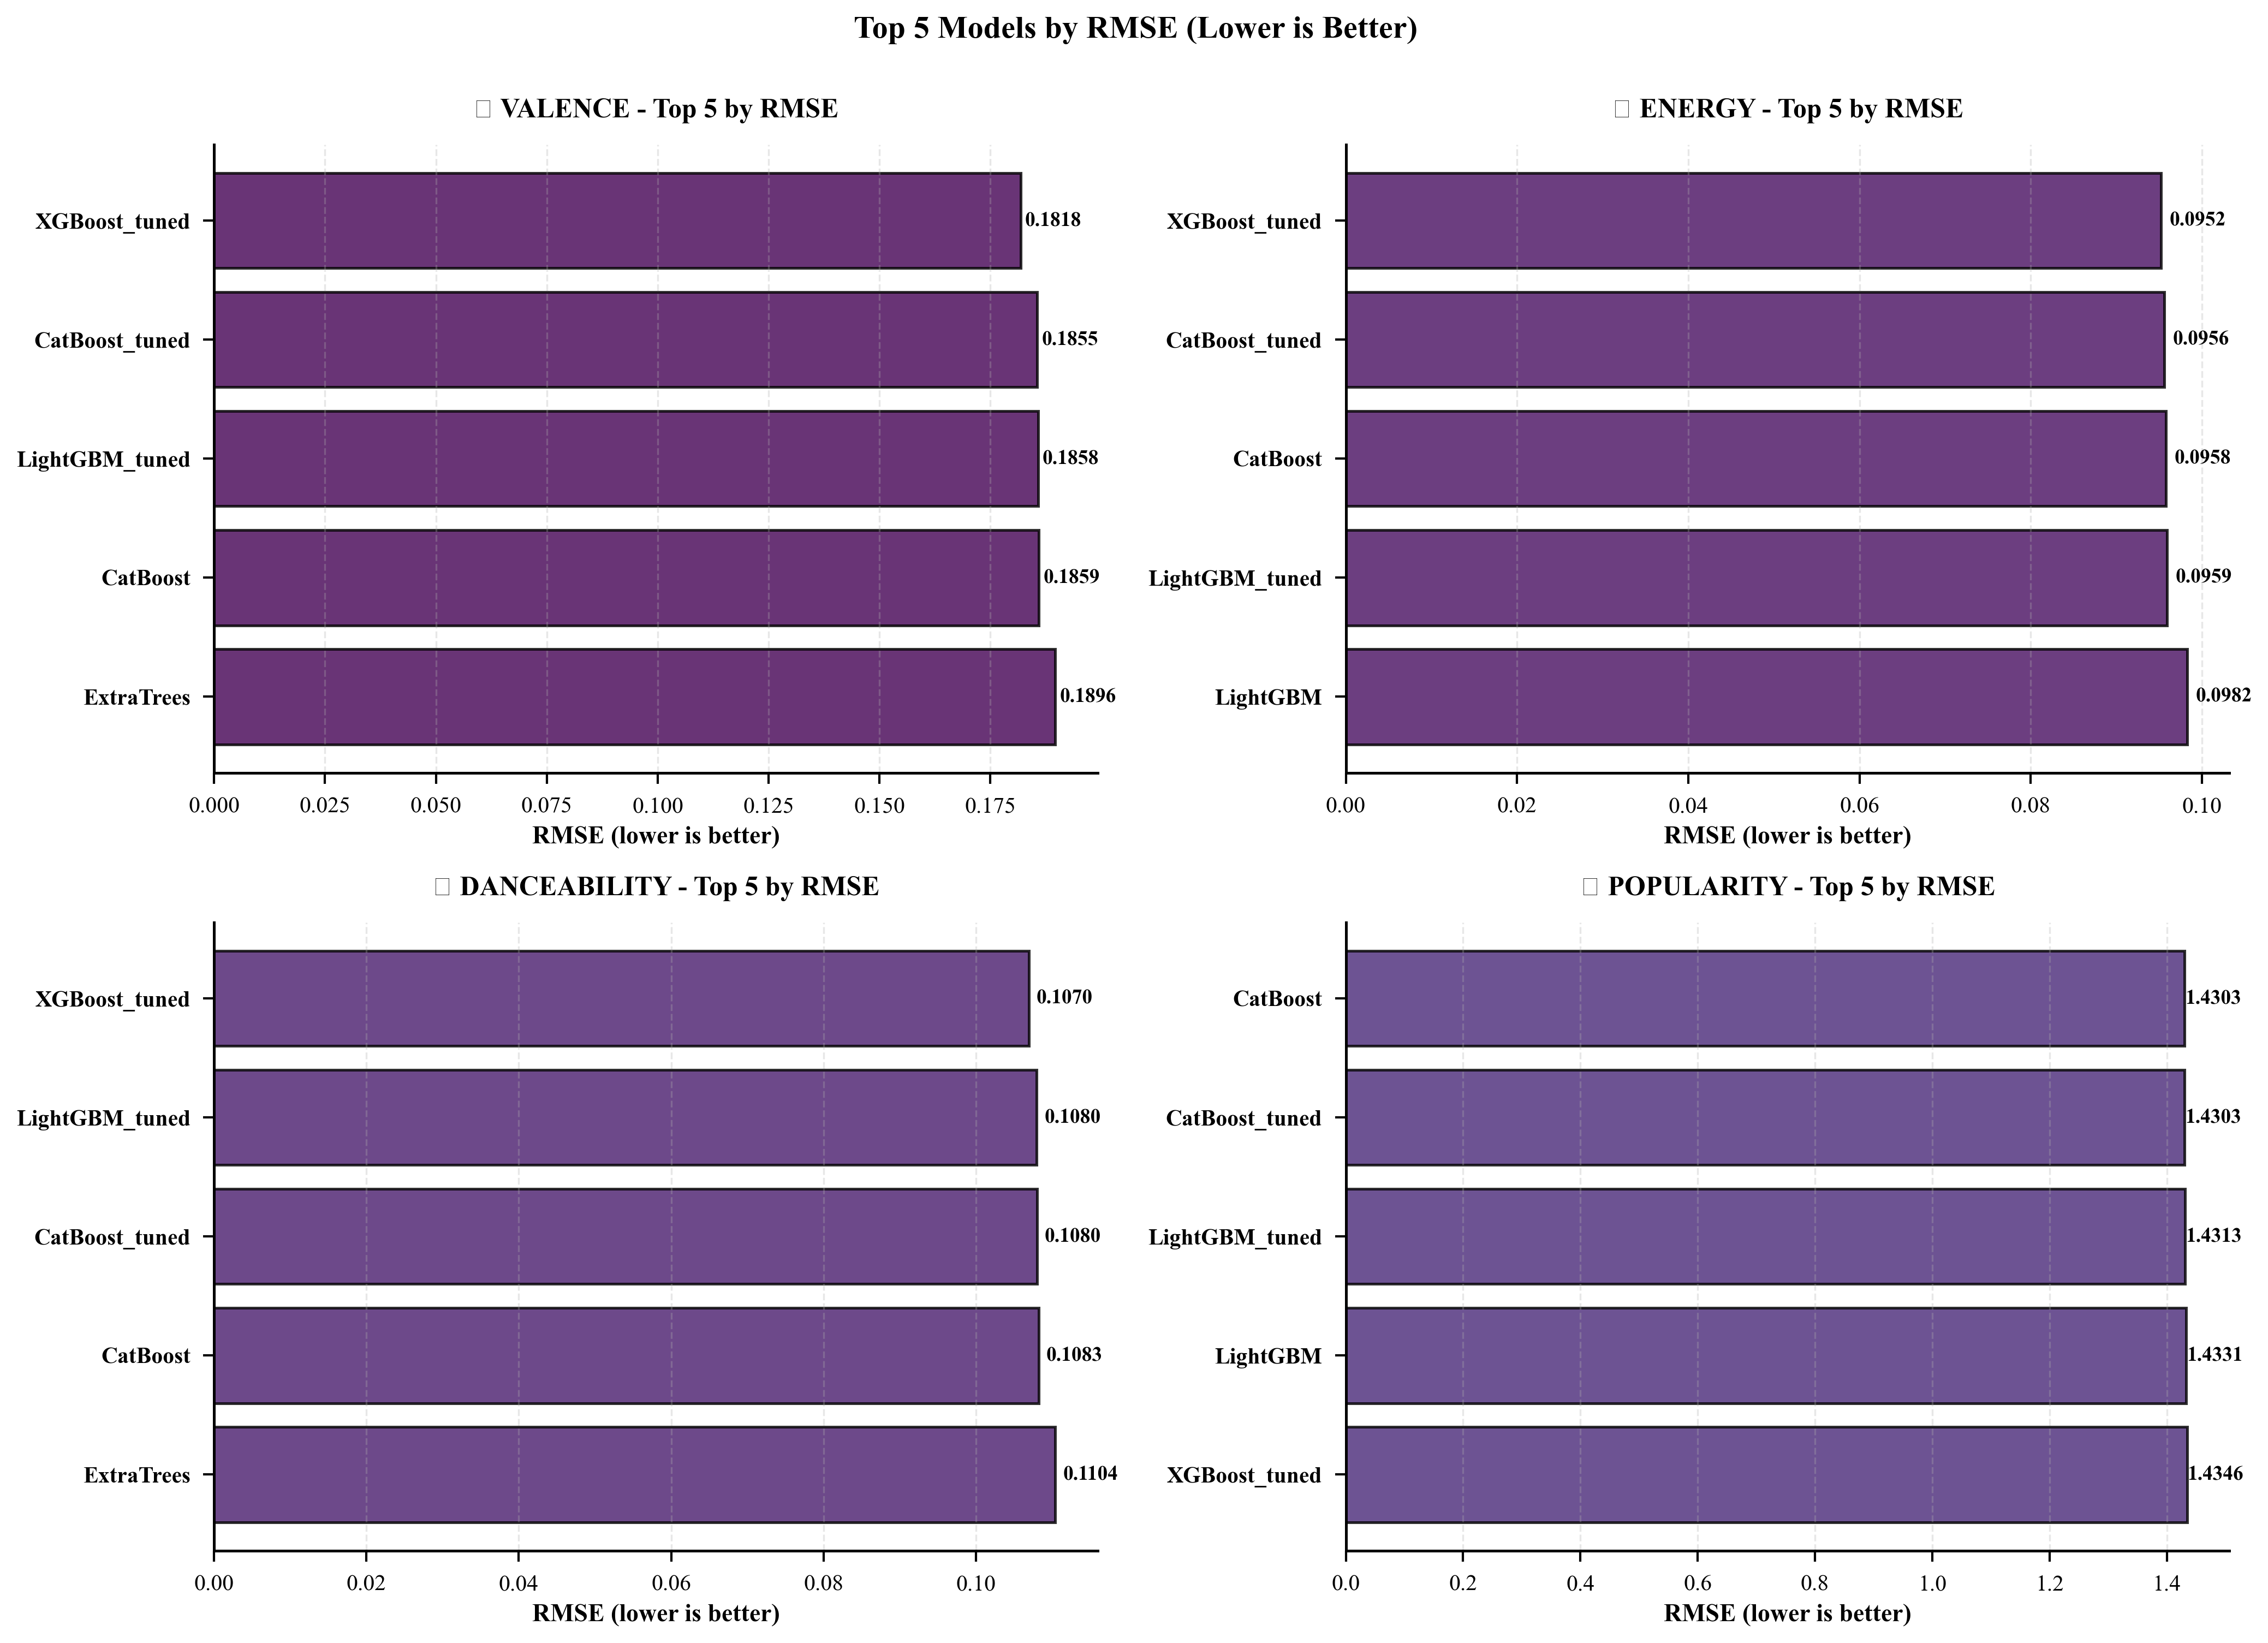

💾 Saved: results/figures/enhanced_top5_rmse.png


In [12]:
# Create RMSE comparison (lower is better)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, target, color, emoji in zip(axes.flatten(), targets, colors, emojis):
    top5 = df[df['target'] == target].nsmallest(5, 'rmse')  # Smallest RMSE = best
    
    bars = ax.barh(top5['model'], top5['rmse'], color=color, edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_xlabel('RMSE (lower is better)', fontsize=11, fontweight='bold')
    ax.set_title(f'{emoji} {target.upper()} - Top 5 by RMSE', fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top5['rmse']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.suptitle('Top 5 Models by RMSE (Lower is Better)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/enhanced_top5_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_top5_rmse.png")

---
## 🔬 Default vs Tuned Models Comparison

In [13]:
# Compare default vs tuned versions
tuned_models = df[df['model'].str.contains('_tuned')].copy()
tuned_models['base_model'] = tuned_models['model'].str.replace('_tuned', '')

default_models = df[~df['model'].str.contains('_tuned') & ~df['model'].isin(['Mean'])].copy()
default_models['base_model'] = default_models['model']

# Merge to compare
comparison = tuned_models.merge(
    default_models[['target', 'base_model', 'r2', 'rmse']], 
    on=['target', 'base_model'], 
    suffixes=('_tuned', '_default')
)
comparison['r2_improvement'] = comparison['r2_tuned'] - comparison['r2_default']
comparison['rmse_improvement'] = comparison['rmse_default'] - comparison['rmse_tuned']  # Positive = better

# Display improvement summary
improvement_summary = comparison.groupby('base_model').agg({
    'r2_improvement': 'mean',
    'rmse_improvement': 'mean'
}).sort_values('r2_improvement', ascending=False)

print("🔧 Tuning Impact (Average across all targets):")
print("="*50)
styled_improvement = improvement_summary.style.format({
    'r2_improvement': '{:+.4f}',
    'rmse_improvement': '{:+.4f}'
}).background_gradient(cmap='RdYlGn', subset=['r2_improvement']).set_caption(
    '🔧 Tuning Impact: Positive = Improvement'
)
display(styled_improvement)

🔧 Tuning Impact (Average across all targets):


,r2_improvement,rmse_improvement
base_model,,
KNeighbors,+0.0806,+0.0247
DecisionTree,+0.0777,+0.1156
LinearSVR,+0.0443,+0.0289
XGBoost,+0.0274,+0.0063
LightGBM,+0.0195,+0.0036
AdaBoost,+0.0155,+0.0049
CatBoost,+0.0011,+0.0002
Lasso,+0.0000,+0.0000
Ridge,-0.0000,-0.0000


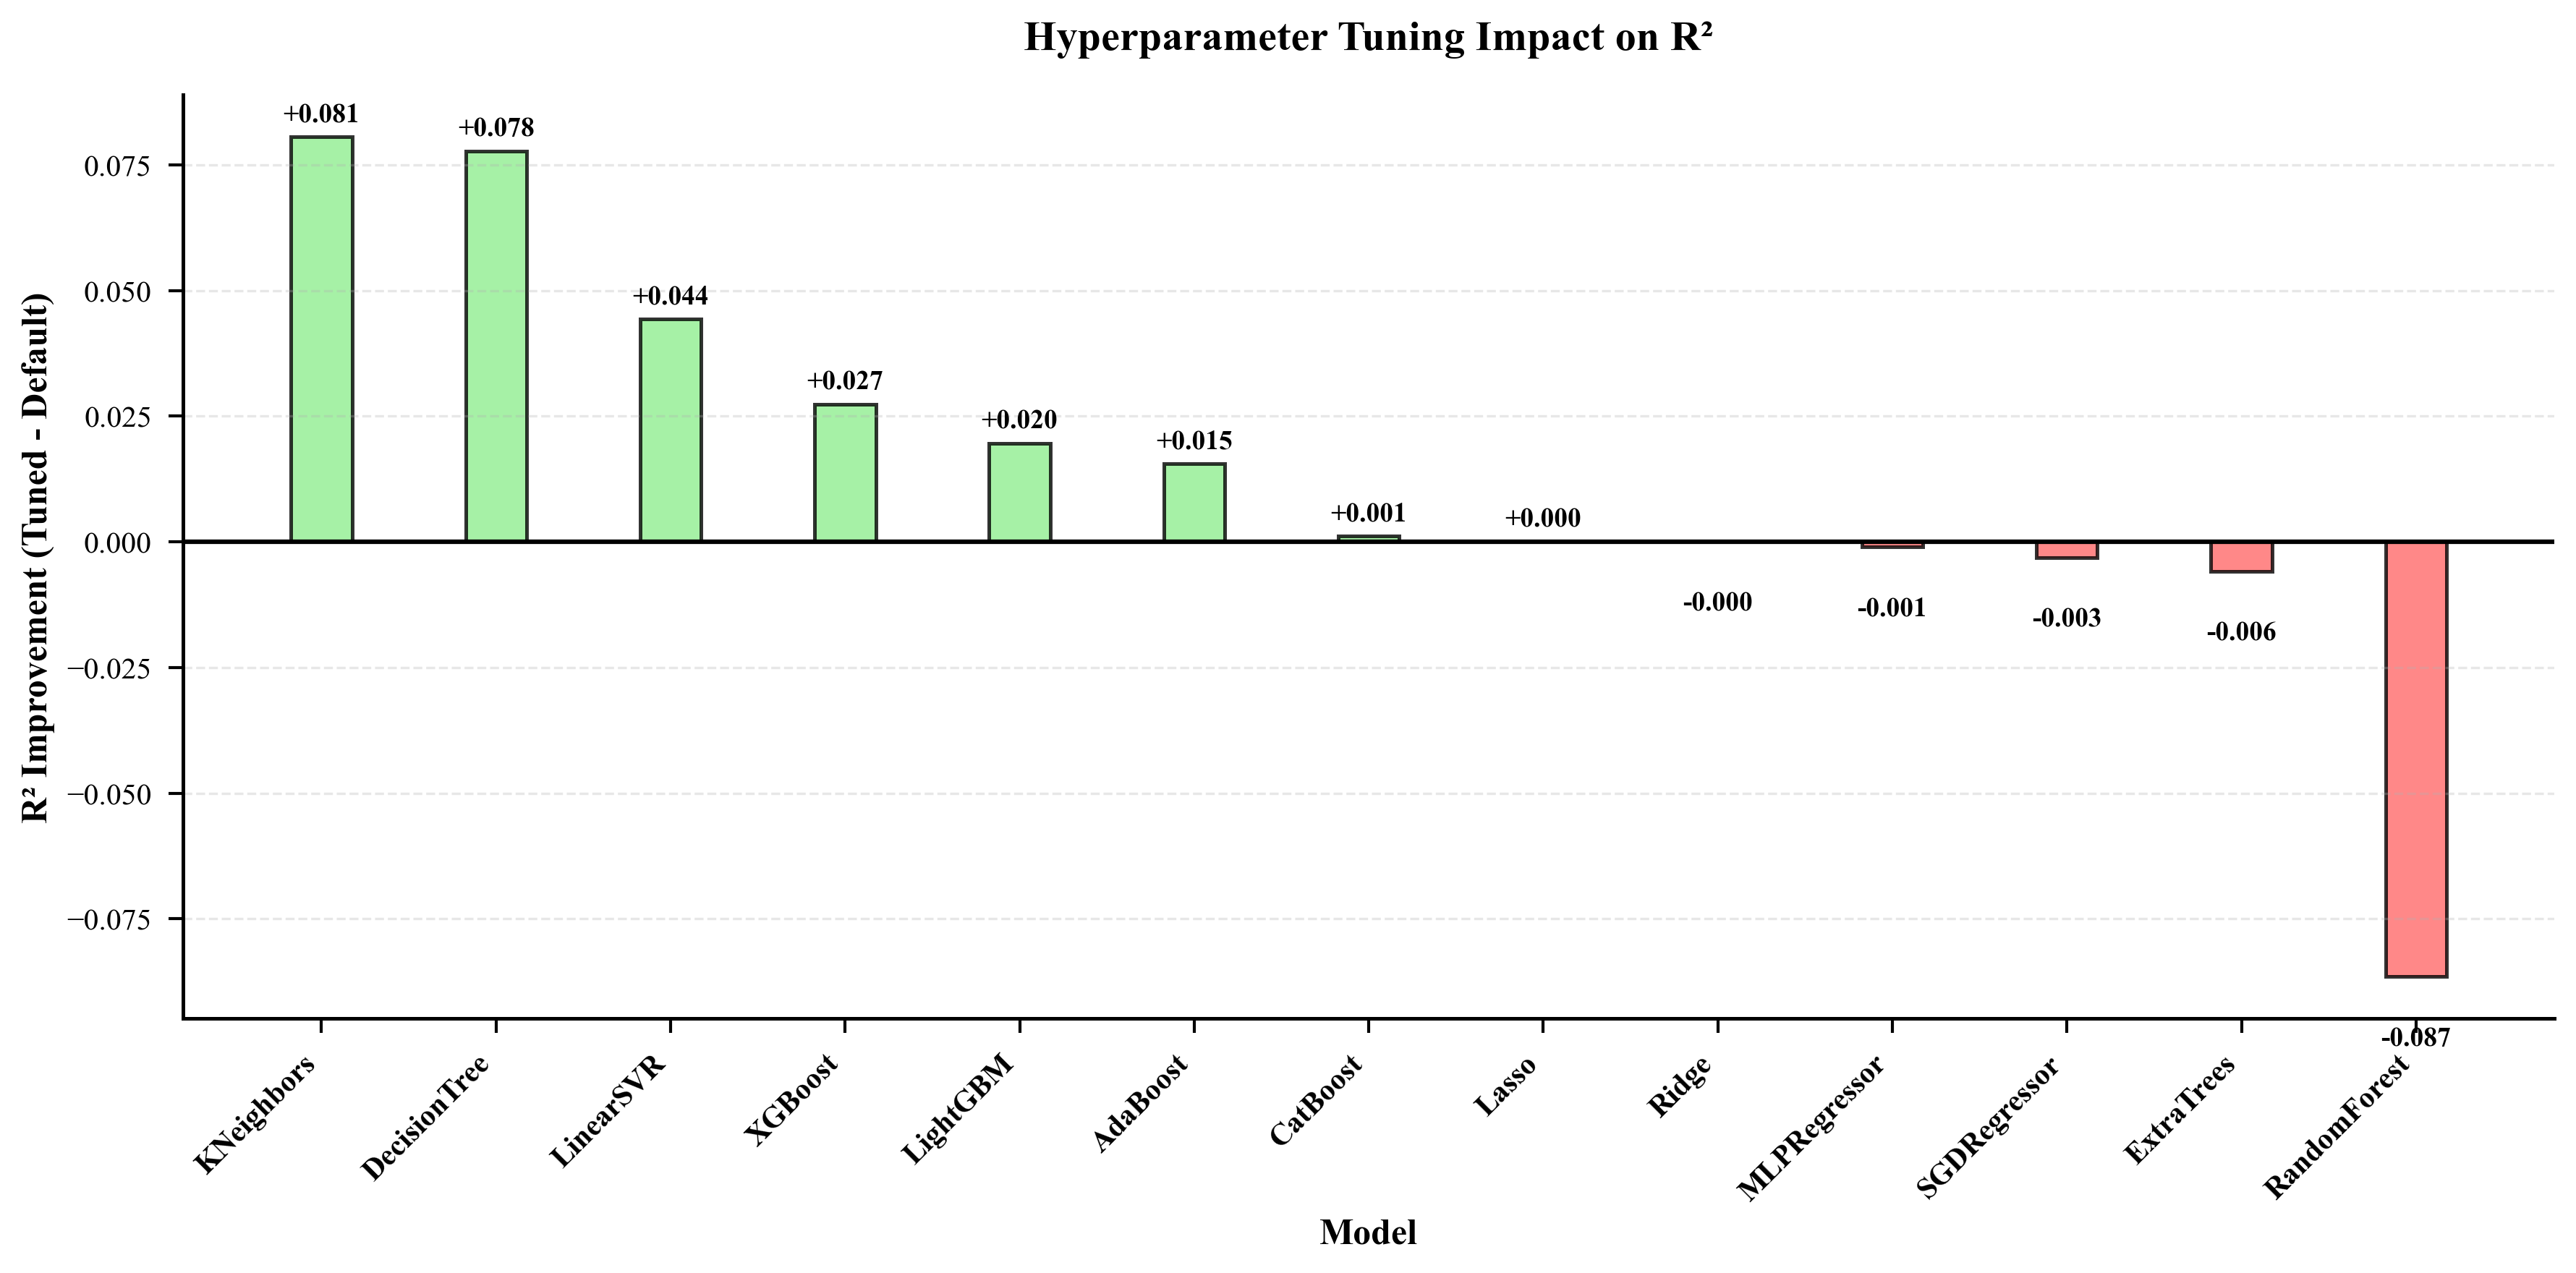

💾 Saved: results/figures/enhanced_tuning_impact.png


In [14]:
# Visualize tuning impact
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(improvement_summary))
width = 0.35

bars = ax.bar(x, improvement_summary['r2_improvement'], width, 
              color=['#90EE90' if v > 0 else '#FF6B6B' for v in improvement_summary['r2_improvement']],
              edgecolor='black', alpha=0.8, linewidth=1.2)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Improvement (Tuned - Default)', fontsize=12, fontweight='bold')
ax.set_title('Hyperparameter Tuning Impact on R²', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(improvement_summary.index, rotation=45, ha='right', fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for bar, val in zip(bars, improvement_summary['r2_improvement']):
    y_pos = val + 0.002 if val >= 0 else val - 0.01
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.3f}', 
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/enhanced_tuning_impact.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_tuning_impact.png")

---
## 📋 Complete Results Table (All Models, All Targets)

In [15]:
# Create comprehensive table
full_table = df[['target', 'model', 'r2', 'rmse', 'mae', 'explained_variance', 
                 'pred_mean', 'pred_std', 'residual_mean', 'residual_std', 'train_time_seconds']].copy()
full_table = full_table.sort_values(['target', 'r2'], ascending=[True, False])

def color_by_target(val):
    colors = {
        'valence': 'background-color: #E8F4FD',
        'energy': 'background-color: #FDF4E8',
        'danceability': 'background-color: #F4E8FD',
        'popularity': 'background-color: #E8FDF4'
    }
    return colors.get(val, '')

styled_full = full_table.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}',
    'explained_variance': '{:.4f}',
    'pred_mean': '{:.4f}',
    'pred_std': '{:.4f}',
    'residual_mean': '{:.4f}',
    'residual_std': '{:.4f}',
    'train_time_seconds': '{:.1f}'
}).applymap(color_by_target, subset=['target']).set_caption(
    '📋 Complete Results - All Models, All Targets'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white')]},
])

display(styled_full)

,target,model,r2,rmse,mae,explained_variance,pred_mean,pred_std,residual_mean,residual_std,train_time_seconds
73,danceability,XGBoost_tuned,0.6092,0.1070,0.0842,0.6092,0.5300,0.1298,-0.0010,0.1070,478.8
77,danceability,LightGBM_tuned,0.6016,0.1080,0.0851,0.6016,0.5304,0.1315,-0.0014,0.1080,55.7
75,danceability,CatBoost_tuned,0.6015,0.1080,0.0851,0.6016,0.5305,0.1315,-0.0015,0.1080,670.2
74,danceability,CatBoost,0.5998,0.1083,0.0854,0.5998,0.5303,0.1314,-0.0013,0.1082,153.4
68,danceability,ExtraTrees,0.5834,0.1104,0.0852,0.5834,0.5289,0.1212,0.0001,0.1104,996.8
72,danceability,XGBoost,0.5787,0.1111,0.0875,0.5788,0.5305,0.1330,-0.0015,0.1110,64.7
66,danceability,RandomForest,0.5778,0.1112,0.0869,0.5779,0.5295,0.1235,-0.0005,0.1112,4618.2
76,danceability,LightGBM,0.5707,0.1121,0.0888,0.5708,0.5305,0.1268,-0.0015,0.1121,20.8
83,danceability,MLPRegressor_tuned,0.5650,0.1128,0.0890,0.5654,0.5259,0.1352,0.0031,0.1128,134.1
82,danceability,MLPRegressor,0.5638,0.1130,0.0891,0.5638,0.5306,0.1366,-0.0016,0.1130,68.3


---
## 🎯 Final Recommendations

In [16]:
# Get top 2 models per target
recommendations = []
for target in targets:
    top2 = df[df['target'] == target].nlargest(2, 'r2')[['target', 'model', 'r2', 'rmse', 'train_time_seconds']]
    top2['recommendation'] = ['🥇 Primary', '🥈 Backup']
    recommendations.append(top2)

rec_df = pd.concat(recommendations)

styled_rec = rec_df.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'train_time_seconds': '{:.1f}s'
}).set_caption('🎯 Final Model Recommendations for Test Evaluation').set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#2E86AB')]},
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white')]},
])

display(styled_rec)

print("\n" + "="*60)
print("📊 SUMMARY")
print("="*60)
for target in targets:
    best = df[df['target'] == target].nlargest(1, 'r2').iloc[0]
    print(f"\n{target.upper()}:")
    print(f"  Best Model: {best['model']}")
    print(f"  R² = {best['r2']:.4f} | RMSE = {best['rmse']:.4f}")

,target,model,r2,rmse,train_time_seconds,recommendation
17,valence,XGBoost_tuned,0.4659,0.1818,767.2s,🥇 Primary
19,valence,CatBoost_tuned,0.4438,0.1855,670.0s,🥈 Backup
45,energy,XGBoost_tuned,0.8487,0.0952,411.7s,🥇 Primary
47,energy,CatBoost_tuned,0.8476,0.0956,652.4s,🥈 Backup
73,danceability,XGBoost_tuned,0.6092,0.1070,478.8s,🥇 Primary
77,danceability,LightGBM_tuned,0.6016,0.1080,55.7s,🥈 Backup
102,popularity,CatBoost,0.0783,1.4303,153.3s,🥇 Primary
103,popularity,CatBoost_tuned,0.0782,1.4303,491.2s,🥈 Backup



📊 SUMMARY

VALENCE:
  Best Model: XGBoost_tuned
  R² = 0.4659 | RMSE = 0.1818

ENERGY:
  Best Model: XGBoost_tuned
  R² = 0.8487 | RMSE = 0.0952

DANCEABILITY:
  Best Model: XGBoost_tuned
  R² = 0.6092 | RMSE = 0.1070

POPULARITY:
  Best Model: CatBoost
  R² = 0.0783 | RMSE = 1.4303


---
## ✅ Next Steps

Based on this analysis:

1. **Run test evaluation** on the recommended models (one-time final evaluation)
2. **Feature importance analysis** for the winning models
3. **Archive Experiment 1 results** before starting Experiment 2 (with artist features)
4. **Document findings** for thesis